In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_bin_occupancy(gt_np, pred_np, max_points=200_000):
    """
    Plot bin occupancy:
      x-axis: flattened spatial index (H*W)
      y-axis: bin index (0..N_bins-1)

    Args:
        gt_np (np.ndarray): GT histogram, shape (B, H, W)
        pred_np (np.ndarray): Pred histogram, shape (B, H, W)
    """
    assert gt_np.shape == pred_np.shape
    assert gt_np.ndim == 3

    B, H, W = gt_np.shape
    N_bins = H * W  # e.g. 128

    # --- Reshape to (B, N_bins) ---
    gt_hist = gt_np.reshape(B, N_bins)
    pred_hist = pred_np.reshape(B, N_bins)

    # --- Build coordinates ---
    # x = flattened spatial index
    # y = bin index where value != 0
    x_gt, y_gt = [], []
    x_pr, y_pr = [], []

    for b in range(B):
        nz_bins_gt = np.nonzero(gt_hist[b])[0]
        nz_bins_pr = np.nonzero(pred_hist[b])[0]

        # x = spatial index (repeated)
        x_gt.append(np.full_like(nz_bins_gt, b))
        y_gt.append(nz_bins_gt)

        x_pr.append(np.full_like(nz_bins_pr, b))
        y_pr.append(nz_bins_pr)

    x_gt = np.concatenate(x_gt)
    y_gt = np.concatenate(y_gt)

    x_pr = np.concatenate(x_pr)
    y_pr = np.concatenate(y_pr)

    # --- Optional subsampling ---
    if x_gt.size > max_points:
        idx = np.random.choice(x_gt.size, max_points, replace=False)
        x_gt, y_gt = x_gt[idx], y_gt[idx]

    if x_pr.size > max_points:
        idx = np.random.choice(x_pr.size, max_points, replace=False)
        x_pr, y_pr = x_pr[idx], y_pr[idx]

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    plt.scatter(
        y_gt,
        x_gt,
        s=4,
        alpha=0.5,
        label="GT",
    )

    plt.scatter(
        y_pr,
        x_pr,
        s=4,
        alpha=0.5,
        label="Pred",
    )

    plt.xlabel("Flattened Spatial Index (H×W)")
    plt.ylabel("Bin Index (0–127)")
    plt.xlim(0, N_bins - 1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


(128, 32, 32)
(128, 32, 32)


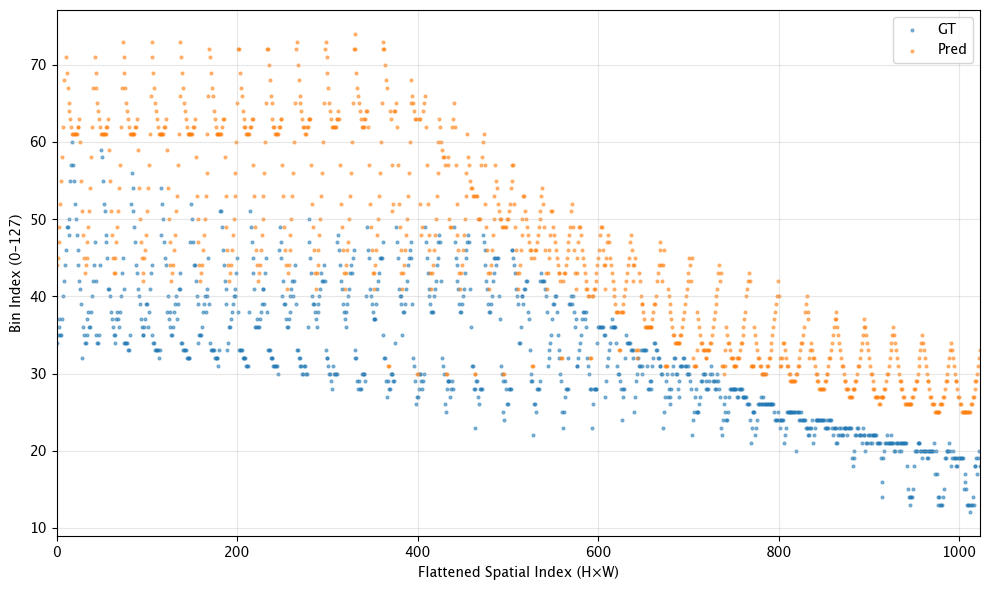

In [2]:
import numpy as np

tsr1 = np.load("depth_histogram_downscaled.npy")
tsr2 = np.load("gt_transi.npy")

print(tsr1.shape)
print(tsr2.shape)

plot_bin_occupancy(tsr1, tsr2)